In [27]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# Load the Face Image
faceImage = cv2.imread('picc.jpg')

Text(0.5, 1.0, 'Face')

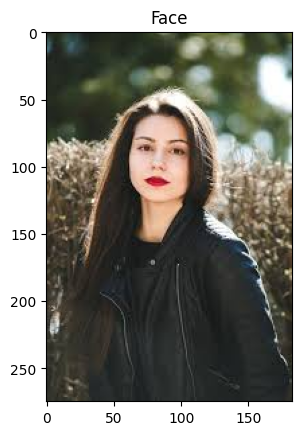

In [29]:
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")

In [30]:
faceImage.shape

(275, 183, 3)

In [31]:
#resized_faceImage.shape
faceImage.shape

(275, 183, 3)

Text(0.5, 1.0, 'glassPNG')

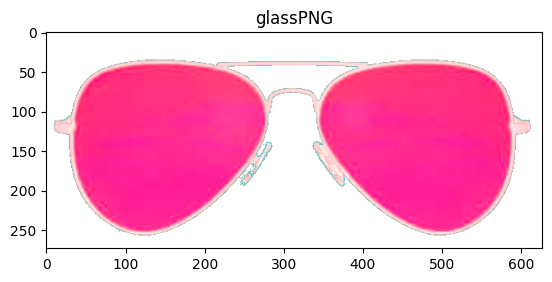

In [32]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('sunn.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [43]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


In [44]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

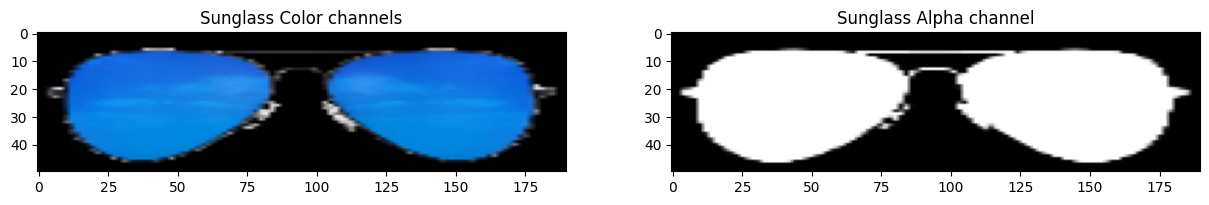

In [45]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

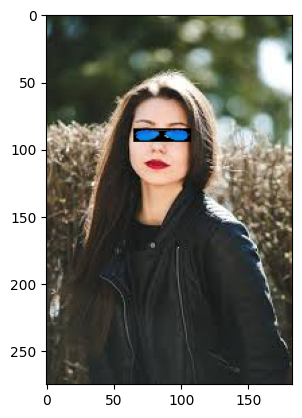

In [50]:
faceWithGlassesNaive = faceImage.copy()

# Correct region (same size as sunglasses: 50x100)
glass_resized=cv2.resize(glassBGR,(43,10))
faceWithGlassesNaive[85:95, 65:108] = glass_resized

plt.imshow(faceWithGlassesNaive[:, :, ::-1])

(np.float64(-0.5), np.float64(182.5), np.float64(274.5), np.float64(-0.5))

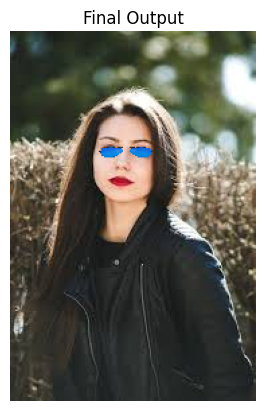

In [51]:
# Resize BOTH glass and mask to SAME size
glass_resized = cv2.resize(glassBGR, (43, 10))
mask_resized  = cv2.resize(glassMask1, (43, 10))

# Convert mask to 3-channel
glassMask = cv2.merge((mask_resized, mask_resized, mask_resized))

# Normalize mask (0 or 1)
glassMask = (glassMask / 255).astype(np.uint8)

# Copy image
faceWithGlassesArithmetic = faceImage.copy()

# Correct ROI (same as your working naive placement)
y1, y2 = 85, 95
x1, x2 = 65, 108

eyeROI = faceWithGlassesArithmetic[y1:y2, x1:x2]

# Apply mask
maskedEye   = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glass_resized, glassMask)

# Combine
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Put back into image
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeRoiFinal

# Show result
plt.imshow(faceWithGlassesArithmetic[:, :, ::-1])
plt.title("Final Output")
plt.axis('off')

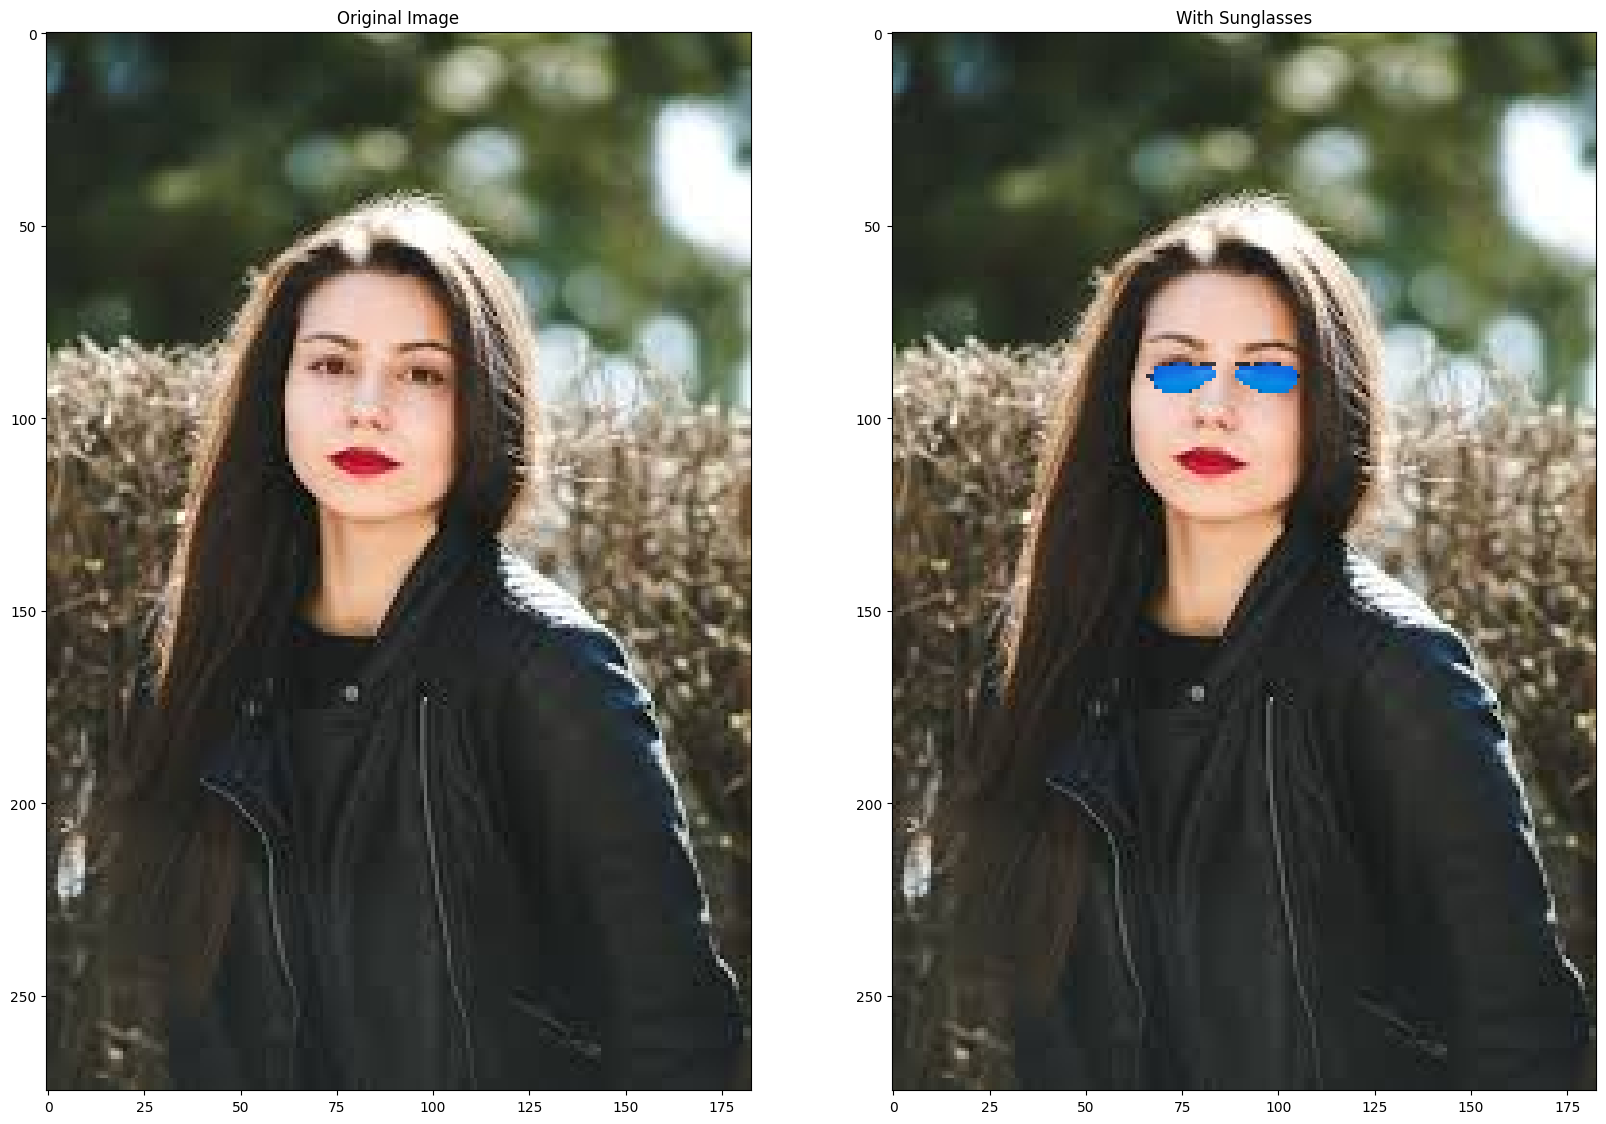

In [53]:
# Replace the eye ROI with the output from the previous section
faceWithGlassesArithmetic[85:95, 65:108]=eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20]);
plt.subplot(121);plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image");
plt.subplot(122);plt.imshow(faceWithGlassesArithmetic[:,:,::-1]);plt.title("With Sunglasses");